MODEL 1: LOGISTIC REGRESSION

In [17]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create StandardScaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


MAKE PREDICTION

In [18]:


y_pred_logistic = logistic_model.predict(X_test_scaled)
print(y_pred_logistic)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


CHECK ACCURACY

In [19]:
from sklearn.metrics import accuracy_score

# Prediction undali
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Accuracy
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.9736842105263158


CLASSIFICATION REPORT

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Disease", "Disease"]
    )
)

              precision    recall  f1-score   support

  No Disease       0.98      0.95      0.96        43
     Disease       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



CONFUSION MATRIX

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)
print(cm)

[[41  2]
 [ 1 70]]


VISUALIZE CONFUSION MATRIX

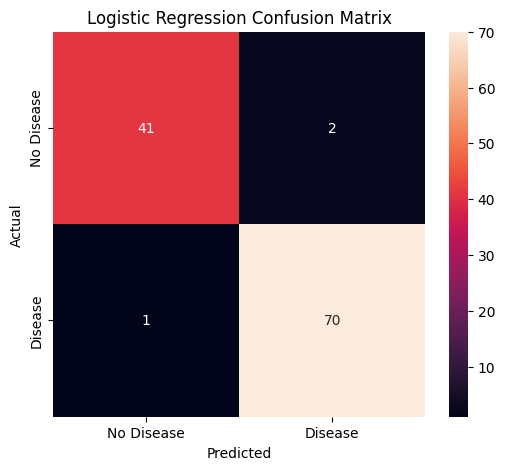

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

MODEL2: SVM

In [24]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM training completed!")

SVM training completed!


SVM PREDICTIONS

In [26]:
from sklearn.metrics import classification_report

y_pred_svm = svm_model.predict(X_test_scaled)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["No Disease", "Disease"]
    )
)

              precision    recall  f1-score   support

  No Disease       1.00      0.95      0.98        43
     Disease       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



SVM ACCURACY

In [27]:
from sklearn.metrics import accuracy_score

y_pred_svm = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9824561403508771


MODEL3: RANDOM FOREST

In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)  # or X_train_scaled, both work for RF

print("Random Forest training completed!")

Random Forest training completed!


RANDOM FOREST PREDICTIONS

In [29]:
from sklearn.metrics import classification_report

y_pred_rf = random_forest_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Disease", "Disease"]
    )
)

              precision    recall  f1-score   support

  No Disease       0.98      0.93      0.95        43
     Disease       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



RANDOM FOREST ACCURACY

In [30]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9649122807017544


MODEL4: XGBOOST

In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


XG BOOST PREDICTIONS

In [32]:
from sklearn.metrics import classification_report

y_pred_xgb = xgb_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Disease", "Disease"]
    )
)

              precision    recall  f1-score   support

  No Disease       0.95      0.93      0.94        43
     Disease       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



COMPARE ALL FOUR MODELS

In [33]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
1                  SVM  0.982456   0.972603  1.000000  0.986111
2        Random Forest  0.964912   0.958904  0.985915  0.972222
3              XGBoost  0.956140   0.958333  0.971831  0.965035


MODEL COMPARISION

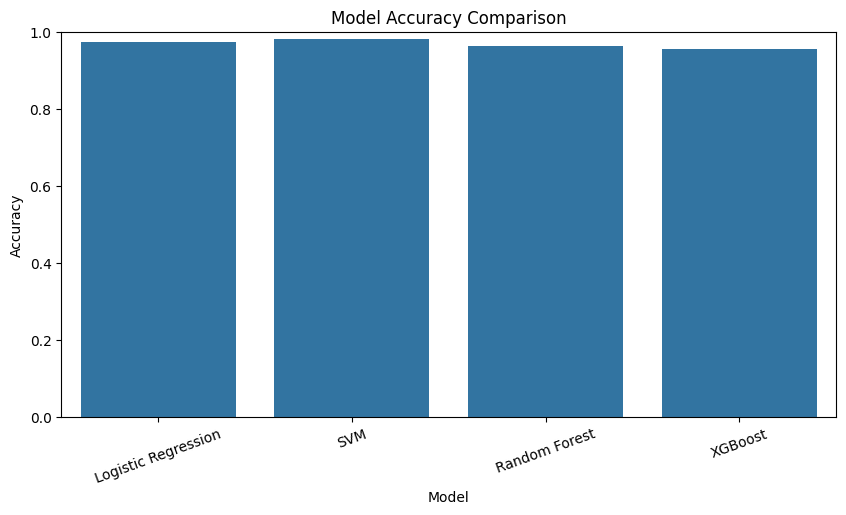

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

plt.show()